In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "4"

import torch
from tts.config.ndaligner.training_module_config import NDAlignerTrainingModuleConfigs
from tts.config.utils.io import load_config
from tts.models.ndaligner import init_nd_aligner_training_module

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
aligner_training_module_cfg_path = "./runs/nd_aligner_vctk_10ms_coupling_dec_20260715-122003/model_config.json"
aligner_training_module_ckpt_path = "./runs/nd_aligner_vctk_10ms_coupling_dec_20260715-122003/checkpoints_timit_bae/best_step_timit_bae_0.020846_step_577500_epoch_33.pth"

TIMIT_ROOT = "/shared/data_zfs/blue2959/TIMIT/TEST"

model_config = load_config(aligner_training_module_cfg_path, NDAlignerTrainingModuleConfigs,)

aligner_training_module = init_nd_aligner_training_module(
    config=model_config,
    device=device,
)
aligner_training_module.load_checkpoint(
    ckpt_path=aligner_training_module_ckpt_path,
    device=device,
)
aligner = aligner_training_module.nd_aligner.eval()

Loading nested state_dict from key 'model' in ./runs/nd_aligner_vctk_10ms_coupling_dec_20260715-122003/checkpoints_timit_bae/best_step_timit_bae_0.020846_step_577500_epoch_33.pth
⚠️ Checkpoint load summary (strict=False):
  - Unexpected top-level modules: ['nd_aligner', 'vocoder']
Checkpoint loading process finished.


In [3]:
wav_path = "/shared/data_zfs/blue2959/TIMIT/TEST/DR1/FAKS0/SA1.WAV"
text = "She had your dark suit in greasy wash water all year."

In [4]:
assert aligner.input_maker is not None

with torch.inference_mode():
    batch = aligner.input_maker.make_with_audio(
        wav_paths=[wav_path],
        scripts=[text],
    )

    features = aligner.compute_alignments(
        x=batch.x,
        x_lengths=batch.x_lengths,
        y=batch.y,
        y_lengths=batch.y_lengths,
        cond=batch.cond, # type: ignore
        compute_soft_path=True,
        compute_hard_path=True,
    )

In [5]:
for i in range(100):
    result = aligner.inference_from_wavs(
        wav_paths = [wav_path],
        texts = [text]
    )

In [6]:
from IPython.display import Audio, display

display(Audio(batch.wav_16k[0].detach().cpu().float().numpy(), rate=16000))

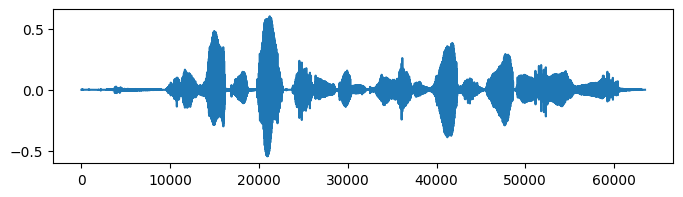

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))
plt.plot(batch.wav_16k[0].squeeze().detach().cpu().float().numpy())
plt.show()

In [8]:
batch._fields

('x',
 'x_lengths',
 'y',
 'y_lengths',
 'cond',
 'wav_16k',
 'wav_16k_lengths',
 'wav_16k_start_offset',
 'wav_16k_end_offset',
 'texts')

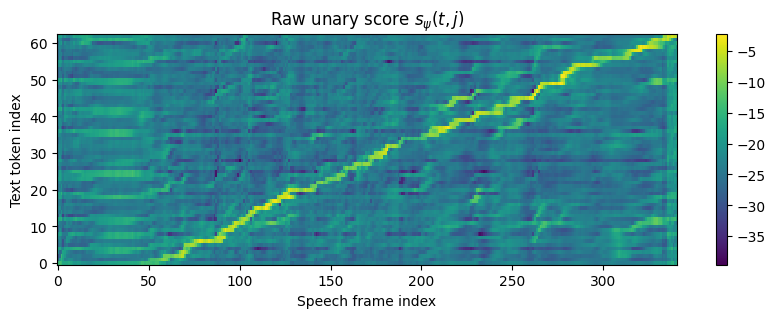

In [9]:
import matplotlib.pyplot as plt

raw_unary = features.raw_unary.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Raw unary score $s_\psi(t,j)$")
plt.colorbar()
plt.show()

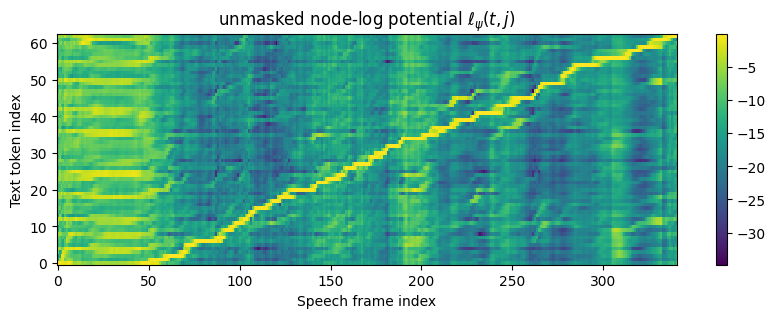

In [10]:
import matplotlib.pyplot as plt

raw_unary = features.log_b.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"unmasked node-log potential $\ell_\psi(t,j)$")
plt.show()

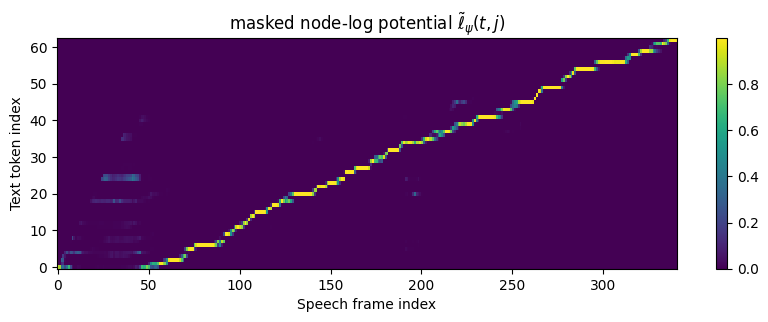

In [11]:
import torch
import matplotlib.pyplot as plt

b = 0
log_b = features.log_b[b]  # (T_s, T_t)

s_len = int(batch.y_lengths[b].item())
t_len = int(batch.x_lengths[b].item())

log_b = log_b[:s_len, :t_len].exp()  # (T_s, T_t)
device = log_b.device

t = torch.arange(s_len, device=device).view(s_len, 1)
j = torch.arange(t_len, device=device).view(1, t_len)

reachable = (j <= t) & ((t_len - 1 - j) <= (s_len - 1 - t))
fill_value = log_b[reachable].min()
masked_log_b = log_b.masked_fill(~reachable, fill_value)
masked_log_b_np = masked_log_b.T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(
    masked_log_b_np,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
)
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"masked node-log potential $\tilde{\ell}_\psi(t,j)$")
plt.show()

In [12]:
def prepare_masked_score_for_plot(
    x: torch.Tensor,
    *,
    neg_threshold: float = -1e8,
    fill_mode: str = "min",  # "mean", "min", "p05"
) -> torch.Tensor:
    """
    x: masked score map, e.g. (T_s, T_t), containing -1e9 invalid entries.

    Returns:
        plot_x: invalid entries replaced for visualization only.
    """
    x = x.detach().float().cpu()

    valid = torch.isfinite(x) & (x > neg_threshold)

    if not valid.any():
        return torch.zeros_like(x)

    valid_values = x[valid]

    if fill_mode == "mean":
        fill_value = valid_values.mean()
    elif fill_mode == "min":
        fill_value = valid_values.min()
    elif fill_mode == "p05":
        fill_value = torch.quantile(valid_values, 0.05)
    else:
        raise ValueError(f"Unknown fill_mode: {fill_mode}")

    plot_x = x.clone()
    plot_x[~valid] = fill_value

    return plot_x

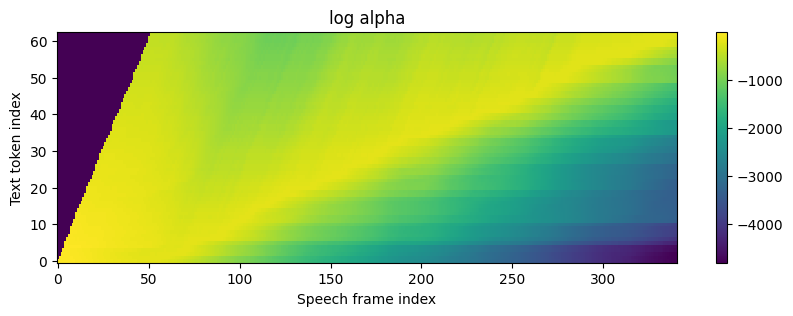

In [13]:
log_alpha = prepare_masked_score_for_plot(features.log_alpha)

plt.figure(figsize=(10, 3))
plt.imshow(
    log_alpha.squeeze(0).T.cpu().detach().numpy(),
    origin="lower",
    aspect="auto",
    interpolation="nearest"
)
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"log alpha")
plt.show()

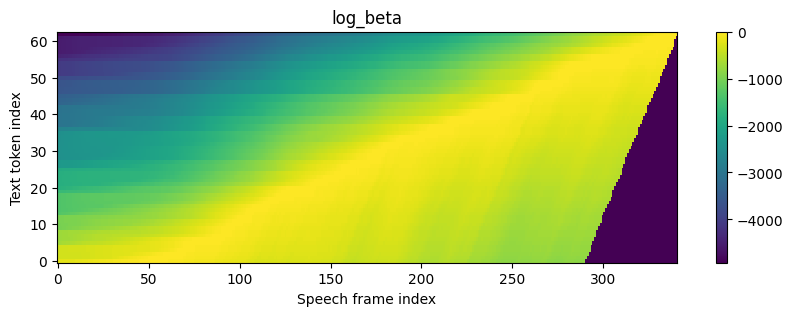

In [14]:
import matplotlib.pyplot as plt

log_beta = prepare_masked_score_for_plot(features.log_beta)

plt.figure(figsize=(10, 3))
plt.imshow(
    log_beta.squeeze(0).T.cpu().detach().numpy(),
    origin="lower",
    aspect="auto",
    interpolation="nearest"
)
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"log_beta")
plt.show()

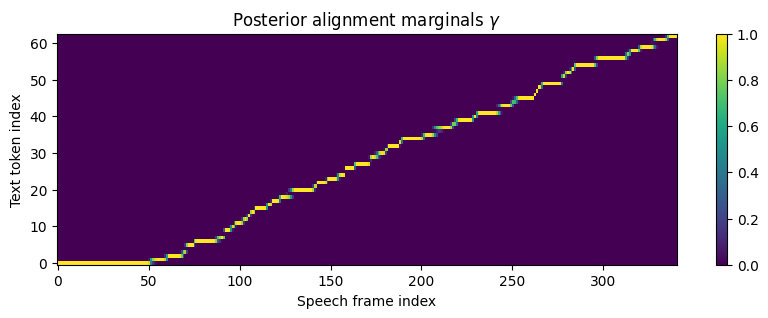

In [15]:
import matplotlib.pyplot as plt

soft_attn = features.soft_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(soft_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Posterior alignment marginals $\gamma$")
plt.show()

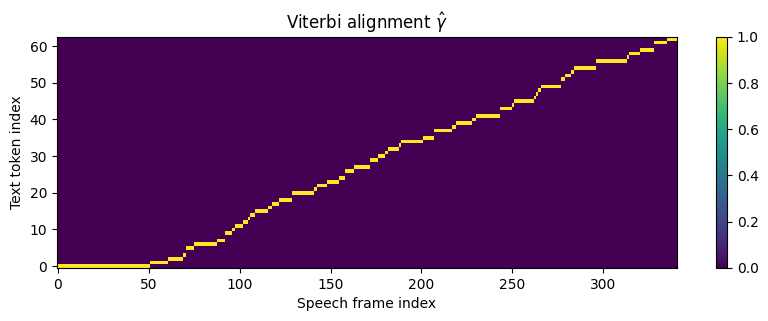

In [16]:
import matplotlib.pyplot as plt

hard_attn = features.hard_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(hard_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Viterbi alignment $\hat{\gamma}$")
plt.show()

In [17]:
wav2_path = "/shared/data_zfs/blue2959/TIMIT/TEST/DR7/FGWR0/SI2208.WAV"
text2 = "Yes, because you didn't run off to use that new toothbrush."

grids = aligner.inference_from_wavs(
    wav_paths=[wav_path, wav2_path],
    texts=[text, text2],
    compute_phone_grid=True,
    compute_word_grid=True,
    include_space_token_to_grid=True,
)

In [18]:
grids.token_ids

tensor([[ 15, 131,  50, 158,  15,  49,  71,  45,  15,  51, 135, 122,  15,  45,
         156,  68, 158, 122,  52,  15,  60, 156,  62, 158,  61,  15, 101,  55,
          15,  91, 122, 156,  50, 158,  67,  50,  15,  64, 156,  68, 158, 131,
          15,  64, 156,  75, 158, 124,  84, 122,  15, 156,  75, 158,  53,  15,
          51, 156, 101, 122,  15,   3,  15,   0,   0],
        [ 15,  51, 156,  85,  60,  15,   2,  15,  43, 101,  52, 156, 138,  67,
          15,  51,  62, 158,  15,  45, 156, 101,  45,  55,  61,  15, 122, 156,
         138,  55,  15, 156,  75,  47,  15,  61,  82,  15,  51, 156,  62, 158,
          67,  15,  80,  71,  61,  15,  55, 156,  62, 158,  15,  61, 156,  62,
         158, 118,  43, 122, 138, 131,  15,   3,  15]], device='cuda:0')

In [19]:
grids.token_lengths

tensor([63, 65], device='cuda:0')

In [20]:
grids.durations

tensor([[51, 10,  8,  2,  0,  4, 13,  4,  0,  4,  2,  4,  3,  1,  3,  7,  2,  4,
          7,  0, 12,  2,  5,  7,  3,  0,  5,  9,  0,  4,  4,  2,  6,  1, 12,  6,
          0, 10,  2,  9,  2, 13,  0,  7,  1, 11,  1,  1,  2, 11,  0,  2,  3,  2,
         12,  0, 17,  1,  6,  8,  0,  7,  6,  0,  0],
        [11,  8, 10,  5, 11,  0,  2,  3,  2,  4,  3,  4,  5,  4,  0,  3,  2,  1,
          3,  4,  1,  4,  2,  4,  2,  0, 10,  2,  6,  1,  0,  5,  9,  7,  0,  6,
          2,  0, 10,  1,  7,  3,  8,  1,  3, 11,  2,  1,  7,  2,  6,  2,  2,  7,
          2,  2,  2,  5,  7,  4,  9, 18,  0,  6,  6]], device='cuda:0')

In [21]:
grids.phones

['ʃiː hæd jʊɹ dˈɑːɹk sˈuːt ɪn ɡɹˈiːzi wˈɑːʃ wˈɔːɾɚɹ ˈɔːl jˈɪɹ .',
 'jˈɛs , bɪkˈʌz juː dˈɪdnt ɹˈʌn ˈɔf tə jˈuːz ðæt nˈuː tˈuːθbɹʌʃ .']

In [22]:
for i in range(2):
    x = aligner.input_maker.tokenizer.decode_to_symbols(grids.token_ids[i, :grids.token_lengths[i]])
    for j in x:
        print(j, end="")
    print()

 ʃiː hæd jʊɹ dˈɑːɹk sˈuːt ɪn ɡɹˈiːzi wˈɑːʃ wˈɔːɾɚɹ ˈɔːl jˈɪɹ . 
 jˈɛs , bɪkˈʌz juː dˈɪdnt ɹˈʌn ˈɔf tə jˈuːz ðæt nˈuː tˈuːθbɹʌʃ . 


In [23]:
from __future__ import annotations

from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


def plot_alignment_with_waveform(
    wav_paths: str | Path | list[str | Path],
    grids,
    sample_idx: int = 0,
    *,
    sr: int | None = None,
    title: str | None = None,
    use_grid_time_range: bool = False,
    margin_sec: float = 0.03,
    figsize: tuple[float, float] = (16, 7),
    waveform_linewidth: float = 0.8,
    boundary_alpha: float = 0.85,
    boundary_linestyle: tuple[int, tuple[int, int]] = (0, (2, 3)),
    word_fontsize: int = 18,
    phone_fontsize: int = 16,
    title_fontsize: int = 22,
    xlabel_fontsize: int = 18,
    space_facecolor: str = "0.85",
    waveform_space_alpha: float = 0.75,
):
    if isinstance(wav_paths, (str, Path)):
        wav_path_list = [wav_paths]
    else:
        wav_path_list = list(wav_paths)

    wav_path = Path(wav_path_list[sample_idx])
    word_grid = grids.word_grid[sample_idx]
    phoneme_grid = grids.phoneme_grid[sample_idx]

    wav, loaded_sr = librosa.load(
        str(wav_path),
        sr=sr,
        mono=True,
    )

    sr_used = loaded_sr
    duration_sec = len(wav) / sr_used
    time_axis = np.arange(len(wav)) / sr_used

    if title is None:
        title = wav_path.stem

    if use_grid_time_range and (
        len(word_grid) > 0
        or len(phoneme_grid) > 0
    ):
        starts = []
        ends = []

        if len(word_grid) > 0:
            starts.append(word_grid[0][0])
            ends.append(word_grid[-1][1])

        if len(phoneme_grid) > 0:
            starts.append(phoneme_grid[0][0])
            ends.append(phoneme_grid[-1][1])

        x_min = max(
            0.0,
            min(starts) - margin_sec,
        )
        x_max = min(
            duration_sec,
            max(ends) + margin_sec,
        )
    else:
        x_min = 0.0
        x_max = duration_sec

    boundary_times: list[float] = []

    for start_sec, end_sec, _ in phoneme_grid:
        boundary_times.append(float(start_sec))
        boundary_times.append(float(end_sec))

    for start_sec, end_sec, _ in word_grid:
        boundary_times.append(float(start_sec))
        boundary_times.append(float(end_sec))

    boundary_times = sorted(set(boundary_times))

    # 공백 구간 수집.
    # word_grid와 phoneme_grid에 동일한 공백이 들어갈 수 있으므로 set으로 중복 제거.
    space_regions = {
        (
            float(start_sec),
            float(end_sec),
        )
        for start_sec, end_sec, label in (
            list(word_grid) + list(phoneme_grid)
        )
        if str(label).strip() == ""
        and float(end_sec) > float(start_sec)
    }

    space_regions = sorted(space_regions)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={
            "height_ratios": [2.2, 1.4, 1.4],
            "hspace": 0.0,
        },
    )

    ax_wav, ax_word, ax_phone = axes

    # ------------------------------------------------------------
    # Waveform
    # ------------------------------------------------------------
    for start_sec, end_sec in space_regions:
        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)

        if vis_end <= vis_start:
            continue

        ax_wav.axvspan(
            vis_start,
            vis_end,
            facecolor=space_facecolor,
            alpha=waveform_space_alpha,
            linewidth=0.0,
            zorder=0,
        )

    ax_wav.plot(
        time_axis,
        wav,
        linewidth=waveform_linewidth,
        zorder=1,
    )
    ax_wav.set_xlim(x_min, x_max)
    ax_wav.set_yticks([])
    # ax_wav.set_title(
    #     title,
    #     fontsize=title_fontsize,
    #     pad=18,
    # )

    # ------------------------------------------------------------
    # Word tier
    # ------------------------------------------------------------
    ax_word.set_ylim(0, 1)
    ax_word.set_yticks([])

    for start_sec, end_sec, label in word_grid:
        start_sec = float(start_sec)
        end_sec = float(end_sec)

        if end_sec < x_min or start_sec > x_max:
            continue

        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)
        width = max(0.0, vis_end - vis_start)

        is_space = str(label).strip() == ""

        rect = Rectangle(
            (vis_start, 0),
            width,
            1,
            facecolor=(
                space_facecolor
                if is_space
                else "none"
            ),
            edgecolor="black",
            linewidth=1.0,
        )
        ax_word.add_patch(rect)

        center = (start_sec + end_sec) / 2.0

        if (
            x_min <= center <= x_max
            and not is_space
        ):
            ax_word.text(
                center,
                0.5,
                str(label),
                ha="center",
                va="center",
                fontsize=word_fontsize,
            )

    # ------------------------------------------------------------
    # Phoneme tier
    # ------------------------------------------------------------
    ax_phone.set_ylim(0, 1)
    ax_phone.set_yticks([])

    for start_sec, end_sec, label in phoneme_grid:
        start_sec = float(start_sec)
        end_sec = float(end_sec)

        if end_sec < x_min or start_sec > x_max:
            continue

        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)
        width = max(0.0, vis_end - vis_start)

        is_space = str(label).strip() == ""

        rect = Rectangle(
            (vis_start, 0),
            width,
            1,
            facecolor=(
                space_facecolor
                if is_space
                else "none"
            ),
            edgecolor="black",
            linewidth=1.0,
        )
        ax_phone.add_patch(rect)

        center = (start_sec + end_sec) / 2.0

        if (
            x_min <= center <= x_max
            and not is_space
        ):
            ax_phone.text(
                center,
                0.5,
                str(label),
                ha="center",
                va="center",
                fontsize=phone_fontsize,
            )

    # ------------------------------------------------------------
    # Alignment boundaries
    # ------------------------------------------------------------
    for t in boundary_times:
        if x_min <= t <= x_max:
            ax_wav.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
                zorder=2,
            )

            ax_word.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
            )

            ax_phone.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
            )

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

    ax_phone.tick_params(
        axis="x",
        labelsize=20,
    )

    ax_phone.set_xlabel(
        "Time (s)",
        fontsize=xlabel_fontsize,
    )

    fig.tight_layout()

    return fig, axes

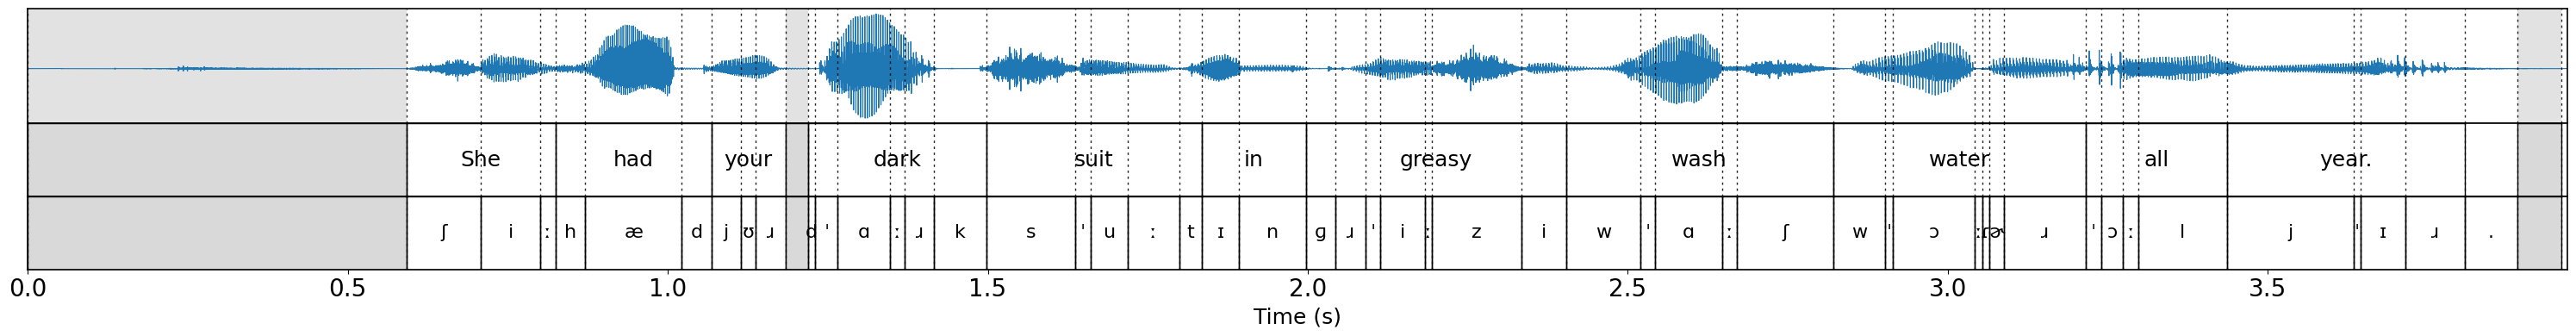

In [24]:
fig, axes = plot_alignment_with_waveform(
    wav_paths=[wav_path, wav2_path],
    grids=grids,
    sample_idx=0,
    use_grid_time_range=False,   # 전체 wav
    figsize=(30, 4)
)